In [1]:
# This notebook is for data exploration of seabird tracks as wells as ocean color data in Google Earth Engine (GEE)

In [1]:
# Imports
import ee
import geemap
import geemap.colormaps as cm
import geedim
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
from shapely.geometry import Point
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt


C:\Users\s44ba\anaconda3_2024\envs\gis5201_project1_GEE\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [2]:
# Custom import from a different folder
import sys
sys.path.append('../project_code')
import project_functions

In [3]:
ee.Authenticate()

True

In [4]:
m1 = geemap.Map()

In [16]:
# ROI
# Format is ee.Geometry.BBox(west, south, east, north)
#roi = ee.Geometry.BBox(-50.0, 35.0, -10.0, 62.0)
roi = ee.Geometry.BBox(-60.0, 40.0, -30.0, 70.0)
m1.center_object(roi)
m1    

Map(bottom=1716.0, center=[48.45835188280866, -30.146484375000004], controls=(WidgetControl(options=['position…

In [50]:
#
# Explore ocean color
#

In [20]:
# A function that returns a single ocean color image, given a date
# Caller must fix scale and offset
def single_ocean_color_image(this_timestamp_datetime,roi):
    # Ocean color collection
    collection = (ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
        .filter(ee.Filter.date("2019-02-01","2019-02-09"))
        .select('chlor_a')
        .filter(ee.Filter.bounds(roi))          
    )
    # return first image from the collection, scaled and offset to degrees C
    first_image = collection.first()
    return first_image

In [21]:
# Use vis params bounds that work for ocean color image
# For single-band images, the palette is used to define how band values get translated into colors
min_val = 0
max_val = 1
vis_params_ocean_color = {
  "min": min_val,
  "max": max_val,
  "palette": ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
}

# Javascript example from https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_MARINE_SATELLITE_OCEAN_COLOR_V6#code-editor-javascript
#var dataset = ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
#                  .filter(ee.Filter.date('2024-06-01', '2024-07-01'));
#var chlorA = dataset.select('chlor_a');
#var chlorAVis = {
#  min: 0,
#  max: 1,
#  palette: ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
#};

In [23]:
# Test function before putting it in the loop
this_timestamp_datetime = datetime(2019,2,5)
this_image = single_ocean_color_image(this_timestamp_datetime,roi)

m1.add_layer(this_image, vis_params_ocean_color, "test_ocean_color_image")
m1

Map(bottom=3185.0, center=[46.89023157359399, -40.05615234375001], controls=(WidgetControl(options=['position'…

In [10]:
roi


ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              -50.0,
              62.0
            ],
            [
              -50.0,
              35.0
            ],
            [
              -10.0,
              35.0
            ],
            [
              -10.0,
              62.0
            ]
          ]
        ]
      },
      "geodesic": {
        "constantValue": false
      }
    }
  }
})

In [52]:
#
# Explore seabird track data (animal telemetry)
# Start with a single csv file
#

In [25]:
# Load animal track csv into pandas dataframe
input_csv_folder = 'C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/'
input_csv_filenames = ["Dataset_1044__Black-legged_Kittiwake_Grumant_GLS_2009_2010_2011.csv", 
                      "Dataset_1038__Black-legged_Kittiwake_Anda_GLS_2009_2010_2011.csv", 
                      "Dataset_1041__Black-legged_Kittiwake_Bulbjerg_GLS_2009_2010_2011.csv", 
                      "Dataset_1043__Black-legged_Kittiwake_Faroe_Islands_GLS_2009_2010.csv", 
                      "Dataset_1049__Black-legged_Kittiwake_Kippaku_GLS_2008_2009_2010_2011.csv"]

input_csv_fullpath = input_csv_folder + input_csv_filenames[1]
df = pd.read_csv(input_csv_fullpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5714 entries, 0 to 5713
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dataset_id         5714 non-null   int64  
 1   scientific_name    5714 non-null   object 
 2   common_name        5714 non-null   object 
 3   site_name          5714 non-null   object 
 4   colony_name        5714 non-null   object 
 5   lat_colony         5714 non-null   float64
 6   lon_colony         5714 non-null   float64
 7   device_type        5714 non-null   object 
 8   bird_id            5714 non-null   int64  
 9   track_id           5714 non-null   object 
 10  original_track_id  5714 non-null   object 
 11  age                5714 non-null   object 
 12  sex                5714 non-null   object 
 13  breed_stage        5714 non-null   object 
 14  breed_status       5714 non-null   object 
 15  date_gmt           5714 non-null   object 
 16  time_gmt           5714 

In [26]:
# Convert to datetime
# Add new column, derived timestamp_datetime, initialized to 1/1/1970
df["timestamp_datetime"] = datetime(1970,1,1)
# Convert
format_string = "%Y-%m-%d %H:%M:%S"
for k in range(len(df)):
    date_string = df.loc[k,"date_gmt"]
    time_string = df.loc[k,"time_gmt"]
    datetime_string = date_string + ' ' + time_string
    df.loc[k,"timestamp_datetime"] = datetime.strptime(datetime_string,format_string)
#endfor

In [27]:
# Fewer columns
df_subset = df[['bird_id','timestamp_datetime','longitude','latitude']]


In [28]:
# Convert to geopandas
geometry = gpd.points_from_xy(df_subset['longitude'],df_subset['latitude'])
gdf_subset = gpd.GeoDataFrame(df_subset,geometry=geometry,crs="EPSG:4326")


In [29]:
# Before converting to movingpandas, we need to set index to timestamp_datetime
gdf_subset.set_index('timestamp_datetime')
print(gdf_subset.head())


   bird_id  timestamp_datetime  longitude  latitude                   geometry
0     8987 2009-08-01 23:08:00   14.94817  68.98749  POINT (14.94817 68.98749)
1     8987 2009-08-02 11:04:00   14.85615  69.04114  POINT (14.85615 69.04114)
2     8987 2009-08-02 23:10:00   15.34520  69.11542   POINT (15.3452 69.11542)
3     8987 2009-08-03 11:02:00   16.07956  69.19673  POINT (16.07956 69.19673)
4     8987 2009-08-03 22:54:00   14.73530  69.49278   POINT (14.7353 69.49278)


In [30]:
# Show unique bird ids
unique_bird_ids = gdf_subset["bird_id"].unique()
print(unique_bird_ids)

[8987 8988 8986 8997 8984 8992 8979 8976 8993 8982 8977 8974]


<Axes: xlabel='bird_id'>

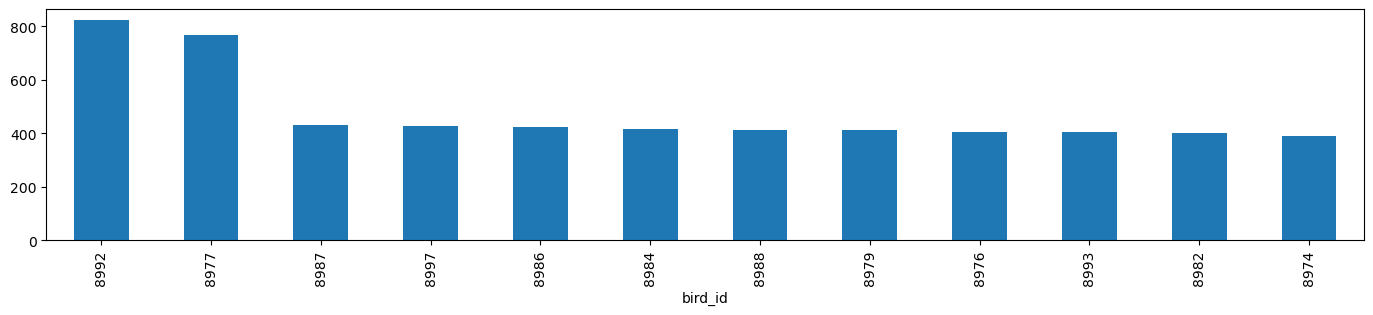

In [31]:
# How many records per unique id?
df["bird_id"].value_counts().plot(kind="bar", figsize=(17, 3))

In [32]:
# Convert to movingpandas
this_bird_id = 8977        
traj = mpd.Trajectory(gdf_subset, this_bird_id, traj_id_col='bird_id', t='timestamp_datetime')
traj.add_speed(overwrite=True)
print(traj.df.describe())

       bird_id    longitude     latitude         speed
count   5355.0  5355.000000  5355.000000   5355.000000
mean    8977.0   -12.914494    62.078409   1681.593643
std        0.0    31.432190     8.992790   3451.330923
min     8977.0   -60.093510    34.660540      0.031239
25%     8977.0   -47.012525    54.352970    210.710741
50%     8977.0    -7.194020    64.900030    457.915935
75%     8977.0    15.546895    69.330330   1492.049273
max     8977.0    53.884540    84.821060  40415.129427


<Axes: >

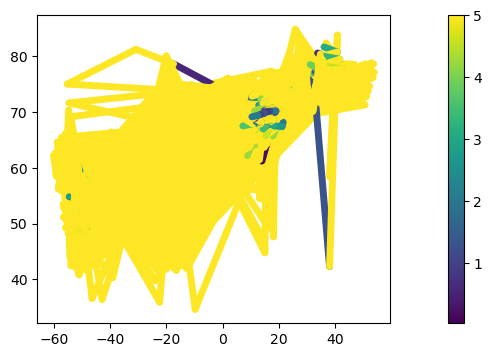

In [33]:
# Plot speed
traj.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True, vmax=5)

In [34]:
# Try trajectory collection
tc = mpd.TrajectoryCollection(
    gdf_subset, "bird_id", t='timestamp_datetime')
tc


TrajectoryCollection with 12 trajectories

In [35]:
tc.add_speed(overwrite=True)

TrajectoryCollection with 12 trajectories

In [36]:
# Convert movingpandas trajectory back to geopandas dataframe, so we can filter it more easily
gdf_with_speed = tc.to_point_gdf()
gdf_with_speed.describe()

,bird_id,longitude,latitude,speed
count,5714.000000,5714.000000,5714.000000,5714.000000
mean,8984.735212,-12.211519,62.267551,2.404841
std,7.014780,31.360098,8.897712,2.662675
min,8974.000000,-60.093510,34.660540,0.008211
25%,8977.000000,-46.863377,54.589962,1.062071
50%,8986.000000,6.925200,65.610895,1.807839
75%,8992.000000,15.626973,69.361185,2.931771
max,8997.000000,53.884540,84.821060,59.087657


In [37]:
gdf_stops = gdf_with_speed[gdf_with_speed["speed"]<0.5]

<Axes: >

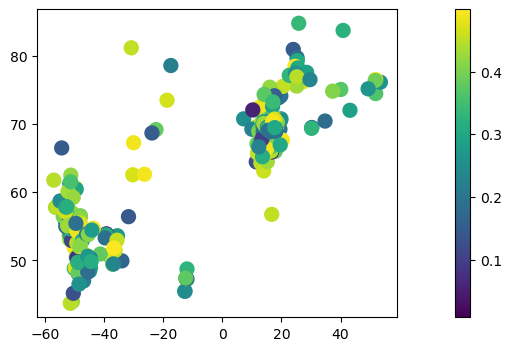

In [38]:
gdf_stops.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)


In [39]:
gdf_transit = gdf_with_speed[gdf_with_speed["speed"].between(10,20)]

<Axes: >

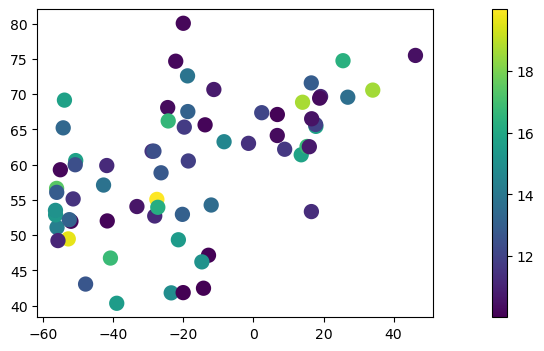

In [40]:
gdf_transit.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)

[8987 8988 8986 8997 8984 8992 8979 8976 8993 8982 8977 8974]


<Axes: >

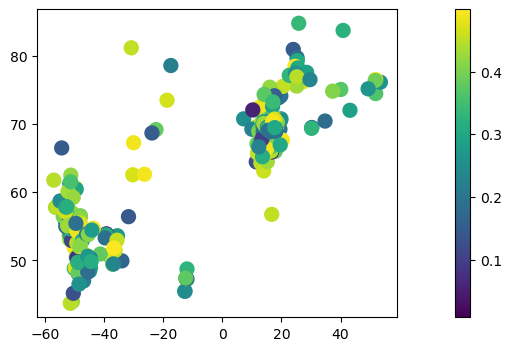

In [41]:
# Try calling code in project_functions to get "stops"
speed_min = 0.0
speed_max = 0.5
gdf_stops = project_functions.get_gdf_with_speed(input_csv_fullpath, speed_min, speed_max)
gdf_stops.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)


[8987 8988 8986 8997 8984 8992 8979 8976 8993 8982 8977 8974]


<Axes: >

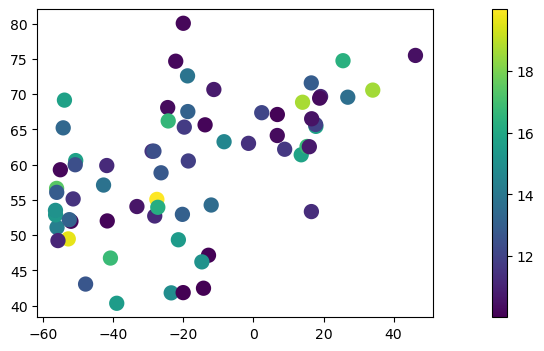

In [42]:
# Similarly, use project_functions for gdf_transit
speed_min = 10.0
speed_max = 20.0
gdf_transit = project_functions.get_gdf_with_speed(input_csv_fullpath, speed_min, speed_max)
gdf_transit.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)

In [ ]:
#
# Explore seabird track data (animal telemetry)
# Loop through csv files
#

In [43]:
# Loop through csv files, aggregating stops
df_list_stops = []
for input_csv_filename in input_csv_filenames:
    # Get fullpath
    input_csv_fullpath = input_csv_folder + input_csv_filename
    # Get stops for this csv file
    print("Processing ", input_csv_fullpath)
    gdf_stops_temp =   project_functions.get_gdf_with_speed(input_csv_fullpath, speed_min=0, speed_max=0.25)
    # Append to list
    df_list_stops.append(gdf_stops_temp)
#endfor

# Concatenate
gdf_stops_combined = pd.concat(df_list_stops, ignore_index=True)

Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1044__Black-legged_Kittiwake_Grumant_GLS_2009_2010_2011.csv
[13103  8840  8855 13124 13117 13110  8860 13112 13076 13099 13093 13104
 13084  8850 13085 13113]
Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1038__Black-legged_Kittiwake_Anda_GLS_2009_2010_2011.csv
[8987 8988 8986 8997 8984 8992 8979 8976 8993 8982 8977 8974]
Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1041__Black-legged_Kittiwake_Bulbjerg_GLS_2009_2010_2011.csv
[13058  8973 13021  8980 13014 13053 13015 13046  8995 13057  8996 13013
 13060]
Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1043__Black-legged_Kittiwake_Faroe_Islands_GLS_2009_2010.csv
[13105 13101  8

In [44]:
gdf_stops_combined.describe()


,bird_id,longitude,latitude,speed
count,672.000000,672.000000,672.000000,672.000000
mean,11267.889881,-26.586478,61.724956,0.163277
std,2158.991489,34.209722,8.454489,0.059964
min,8510.000000,-80.348330,40.837630,0.006575
25%,8976.000000,-56.234190,56.057095,0.119949
50%,13053.000000,-45.499680,60.532510,0.173320
75%,13124.000000,8.856125,68.280892,0.214837
max,13295.000000,73.131740,81.288290,0.249866


<Axes: >

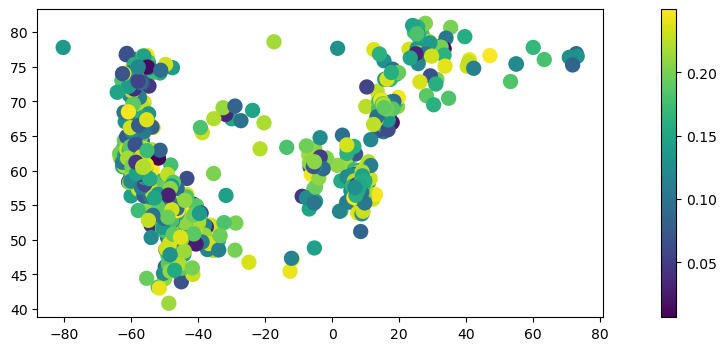

In [45]:
gdf_stops_combined.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)

In [46]:
# Loop through csv files, aggregating transit
df_list_transit = []
for input_csv_filename in input_csv_filenames:
    # Get fullpath
    input_csv_fullpath = input_csv_folder + input_csv_filename
    # Get transit for this csv file
    print("Processing ", input_csv_fullpath)
    gdf_transit_temp =   project_functions.get_gdf_with_speed(input_csv_fullpath, speed_min=10, speed_max=20)
    # Append to list
    df_list_transit.append(gdf_transit_temp)
#endfor

# Concatenate
gdf_transit_combined = pd.concat(df_list_transit, ignore_index=True)

Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1044__Black-legged_Kittiwake_Grumant_GLS_2009_2010_2011.csv
[13103  8840  8855 13124 13117 13110  8860 13112 13076 13099 13093 13104
 13084  8850 13085 13113]
Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1038__Black-legged_Kittiwake_Anda_GLS_2009_2010_2011.csv
[8987 8988 8986 8997 8984 8992 8979 8976 8993 8982 8977 8974]
Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1041__Black-legged_Kittiwake_Bulbjerg_GLS_2009_2010_2011.csv
[13058  8973 13021  8980 13014 13053 13015 13046  8995 13057  8996 13013
 13060]
Processing  C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/Dataset_1043__Black-legged_Kittiwake_Faroe_Islands_GLS_2009_2010.csv
[13105 13101  8

<Axes: >

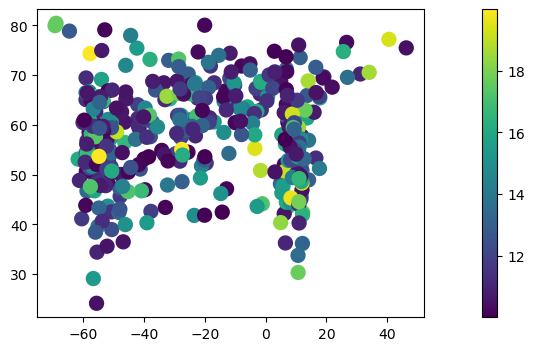

In [47]:
gdf_transit_combined.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)

In [59]:
#
# Integrate seabird tracks with ocean color
#

In [60]:
# Convert geopandas gdf_stops_combined to GEE feature class and add it as a layer to the map
fc_gdf_stops_combined = geemap.gdf_to_ee(gdf_stops_combined)

# Use vis params bounds that work for speeds (0 - 20)
# For single-band images, the palette is used to define how band values get translated into colors
min_val = 0
max_val = 20
vis_params_speed = {
  "min": min_val,
  "max": max_val
}

m1.add_layer(fc_gdf_stops_combined, vis_params_speed, "try_gdf_stops_combined")
m1

# Note that the ocean color here is just for one day, yet the animal telemetry data is over several years...so, not yet a fair comparison...


Map(bottom=1010.0, center=[48.22467264956519, -43.33007812500001], controls=(WidgetControl(options=['position'…